
# 🔬 Activation Maximization

In the foundations notebook, we followed an image **forward** through a convolutional neural network:

> **Pixels → local patterns → feature maps → deeper representations → prediction**

Now we turn the question around.

Instead of asking:

> *“What does this image activate?”*

we ask:

> ## **“What kind of image would make a chosen internal feature activate as strongly as possible?”**

That is the basic idea behind **activation maximization**.

We will use **InceptionV1** model and **Lucent** library to optimize an image directly against an internal channel. The resulting image is not necessarily a natural photograph. Rather, it is a visualization of patterns that strongly excite the selected feature.

<br>

<div align="center">
  <img
    src="https://raw.githubusercontent.com/Cohere-Labs-Community/vision-interpretability-toolkit/main/images/act_max.png""
    style="width:100%; max-width:1600px;"
  >
</div>

<br>




---




## Setup

We use **Lucent**, a PyTorch feature-visualization library inspired by the earlier Lucid work.



In [1]:
# ---------------------------------------------------------
# Install Lucent
# ---------------------------------------------------------

!pip install -q torch-lucent


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 257.1/257.1 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 84.9 MB/s eta 0:00:00


In [2]:
# ---------------------------------------------------------
# Imports
# ---------------------------------------------------------

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

from PIL import Image
from lucent.modelzoo import inceptionv1
from lucent.optvis import render, param




---




## Load InceptionV1

As in the foundations notebook, we use **InceptionV1** as our reference model.

For activation maximization, the model is placed in evaluation mode and its parameters are frozen. Note: **We are not training the network**.

We are going to ask a fixed, already-trained network what kind of visual pattern most strongly activates one of its internal features.


In [3]:
# ---------------------------------------------------------
# Select device
# ---------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")


# ---------------------------------------------------------
# Load pretrained InceptionV1
# ---------------------------------------------------------

def load_model(device):
    """Load pretrained InceptionV1 and freeze its parameters."""

    model = inceptionv1(pretrained=True)
    model = model.to(device)
    model.eval()

    # We only need gradients with respect to the generated image,
    # not with respect to the model weights.
    for parameter in model.parameters():
        parameter.requires_grad = False

    return model


model = load_model(DEVICE)

print("✓ InceptionV1 loaded")


Using device: cuda
Downloading: "https://github.com/ProGamerGov/pytorch-old-tensorflow-models/raw/master/inception5h.pth" to /root/.cache/torch/hub/checkpoints/inception5h.pth


100%|██████████| 27.0M/27.0M [00:00<00:00, 179MB/s] 


✓ InceptionV1 loaded




---




## ❓ What exactly are we maximizing?

A convolutional layer contains many **channels**, each represented by a spatial feature map.

Lucent lets us describe a target using:

```text
layer_name:channel
```

For example:

```text
mixed4a:0
```

means:

> **maximize Channel 0 in layer `mixed4a`.**

During optimization, Lucent repeatedly sends the generated image through the network, measures the target activation, computes the gradient of that activation with respect to the image parameters, and updates the image.

### A terminology note

In informal interpretability discussions, individual channels are sometimes called *neurons*. Technically, however, the objective used in this notebook is a **channel objective**: it encourages a whole feature channel to activate across its spatial map.

That distinction will matter later when we reason about *where* a feature appears in an image.




---




## Parameterizing the image

If we optimize raw pixels directly, gradient-based visualization can easily exploit high-frequency patterns that are effective for the network but difficult for humans to interpret.

Lucent therefore gives us useful image parameterizations.

Here we use:

- **`fft=True`** — optimize through a frequency-based image parameterization.
- **`decorrelate=True`** — use a decorrelated color representation.
- **`device=DEVICE`** — create the optimized image parameters on the same device as the model.

These choices do not tell the model *what* to find. They simply make the optimization better behaved and the resulting visualization easier to inspect.


In [7]:
# ---------------------------------------------------------
# Activation maximization
# ---------------------------------------------------------

def activation_maximization(
    model,
    layer_name,
    channel,
    image_size=512,
    num_steps=1024,
):
    """
    Generate an image that strongly activates one channel
    in a chosen InceptionV1 layer.
    """

    # Lucent interprets "layer:channel" as a channel objective
    objective = f"{layer_name}:{channel}"

    # Parameterize the image using FFT + decorrelated colors
    param_f = lambda: param.image(
        image_size,
        fft=True,
        decorrelate=True,
    )

    # Optimize the image to maximize the chosen channel
    images = render.render_vis(
        model,
        objective,
        param_f=param_f,
        thresholds=(num_steps,),
        show_image=False,
        verbose=False,
    )

    return images[0][0]




---




## 🖼 Visualize one channel

Let's begin with a **single feature**.

We choose a layer and channel, optimize an image for that target, and then inspect the result.

> The visualization should be interpreted as:  
> **“This is a pattern that strongly activates this channel.”**
>
> It should *not* automatically be interpreted as:  
> **“This channel represents exactly this human concept.”**

A channel can respond to multiple related patterns, textures, colors, shapes, or combinations of features. Activation maximization gives us evidence about a feature—not a complete semantic definition.


100%|██████████| 1024/1024 [00:32<00:00, 31.32it/s]


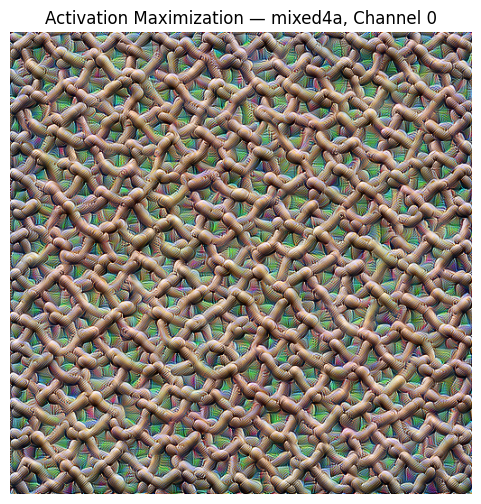

In [8]:
# ---------------------------------------------------------
# Choose one layer and channel
# ---------------------------------------------------------

LAYER = "mixed4a"
CHANNEL = 0

# For high-resolution visualizations:
IMAGE_SIZE = 512
NUM_STEPS = 1024


# ---------------------------------------------------------
# Generate the activation-maximizing image
# ---------------------------------------------------------

generated_image = activation_maximization(
    model,
    layer_name=LAYER,
    channel=CHANNEL,
    image_size=IMAGE_SIZE,
    num_steps=NUM_STEPS,
)


# ---------------------------------------------------------
# Display the result
# ---------------------------------------------------------

plt.figure(figsize=(6, 6))
plt.imshow(np.clip(generated_image, 0, 1))
plt.title(f"Activation Maximization — {LAYER}, Channel {CHANNEL}")
plt.axis("off")
plt.show()




---




## What are we looking at?

The generated image was **not retrieved from a dataset**.

It began as a parameterized synthetic image and was iteratively changed in whatever direction increased the target channel's activation.

That means the result can reveal visual preferences that are difficult to notice by looking at ordinary photographs alone.

But activation maximization also has an important limitation:

> ### A highly activating image tells us what *can* excite a feature—not necessarily what normally excites it in real data.

This is why feature visualization becomes much more informative when paired with another question:

> **Which real dataset images activate this feature most strongly?**

Later in the toolkit, we will put these two views side by side:

```text
ACTIVATION MAXIMIZATION             DATASET EXAMPLES
"What could strongly excite it?"    "What actually excites it in real images?"

            │                                  │
            └──────────────┬───────────────────┘
                           ▼
                richer feature interpretation
```




---




## Generate a collection of channels

For systematic interpretability work, we usually want to visualize more than one channel.

The following cells let you choose:

- a **layer**
- a **range of channels**
- image resolution
- number of optimization steps
- output directory

The images are then generated one at a time and saved using the channel index as the filename.

Note: Activation maximization can be computationally expensive—especially with `512 × 512` images and `1024` optimization steps.



### Optional: save results to Google Drive

The next cell is only needed when running in **Google Colab** and saving a larger collection of generated images persistently.

If you prefer to save only inside the current Colab runtime, skip it and change `OUTPUT_ROOT` in the following cell to a local path.


In [12]:
# ---------------------------------------------------------
# OPTIONAL: Mount Google Drive
# ---------------------------------------------------------

from google.colab import drive
import os

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")
else:
    print("✓ Google Drive already mounted")


✓ Google Drive already mounted


In [13]:
# ---------------------------------------------------------
# Batch configuration
# ---------------------------------------------------------

LAYER = "mixed4a"

# Start small while testing.
# Expand this range once everything is working as expected.
CHANNELS = range(0, 1)

IMAGE_SIZE = 512
NUM_STEPS = 1024

OUTPUT_ROOT = Path("/content/drive/MyDrive/activation_maximization_results")
SAVE_DIR = OUTPUT_ROOT / LAYER

SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Layer:       {LAYER}")
print(f"Channels:    {CHANNELS.start} → {CHANNELS.stop - 1}")
print(f"Image size:  {IMAGE_SIZE} × {IMAGE_SIZE}")
print(f"Steps:       {NUM_STEPS}")
print(f"Save folder: {SAVE_DIR}")


# ---------------------------------------------------------
# Generate and save activation-maximizing images
# ---------------------------------------------------------

for channel in CHANNELS:

    print(f"Generating {LAYER}, channel {channel}...")

    generated_image = activation_maximization(
        model,
        layer_name=LAYER,
        channel=channel,
        image_size=IMAGE_SIZE,
        num_steps=NUM_STEPS,
    )

    # Convert the floating-point image to standard 8-bit RGB.
    image_uint8 = (
        np.clip(generated_image, 0, 1) * 255
    ).astype(np.uint8)

    # Save one image per channel.
    save_path = SAVE_DIR / f"{channel}.jpg"

    Image.fromarray(image_uint8).save(
        save_path,
        quality=95,
    )

print(f"✓ Saved {len(CHANNELS)} image(s) to {SAVE_DIR}")


Layer:       mixed4a
Channels:    0 → 0
Image size:  512 × 512
Steps:       1024
Save folder: /content/drive/MyDrive/activation_maximization_results/mixed4a
Generating mixed4a, channel 0...


100%|██████████| 1024/1024 [00:30<00:00, 33.22it/s]

✓ Saved 1 image(s) to /content/drive/MyDrive/activation_maximization_results/mixed4a




---




## ▶ Things worth experimenting with

Once the basic pipeline works, try changing **one thing at a time**.

| Experiment | What changes? |
|---|---|
| `LAYER = "mixed3a"` → `"mixed4a"` → deeper layers | Which level of the representation you inspect |
| `CHANNEL = 0` → another channel | Which learned feature you optimize |
| `IMAGE_SIZE = 256` → `512` | Output resolution and compute cost |
| `NUM_STEPS = 256` → `1024` | How long the optimization is allowed to refine the image |
| `fft=False` | The image parameterization |
| `decorrelate=False` | The color parameterization |

A useful habit is to avoid assigning a feature a human-readable label from **one visualization alone**.

Instead, ask whether the same interpretation is supported by:

1. activation maximization,
2. highly activating dataset examples,
3. the spatial regions responsible for those activations,
4. and, when needed, causal interventions.

That progression—from *interesting picture* to *supported interpretation*—is a central theme of mechanistic interpretability.




---




# From “what excites it?” to “where do we see it?” 🌱

We have now reversed the usual direction of image classification.

Instead of giving the network an image and observing its activations, we selected an internal feature and **optimized an image around the network's response**.

We can summarize the experiment as:

> **Choose a feature → generate an image → maximize its activation → inspect the resulting pattern**

Activation maximization gives us a powerful first glimpse into what a learned feature may prefer.

But synthetic optimization tells only one side of the story.

A feature might produce a beautiful visualization and still behave differently—or more broadly—on natural images.

So our next question is:

> ## **Which real images from a dataset activate this feature the most?**

That takes us to the next part of the toolkit:

<div align="center">

## → Dataset Examples 🔎

**Synthetic preference + real examples = a much stronger picture of what a feature is doing.**

</div>






---

